category
STRONG_REPULSION        1078
MIXED                    896
STRONG_COINTEGRATION      73
Name: count, dtype: int64


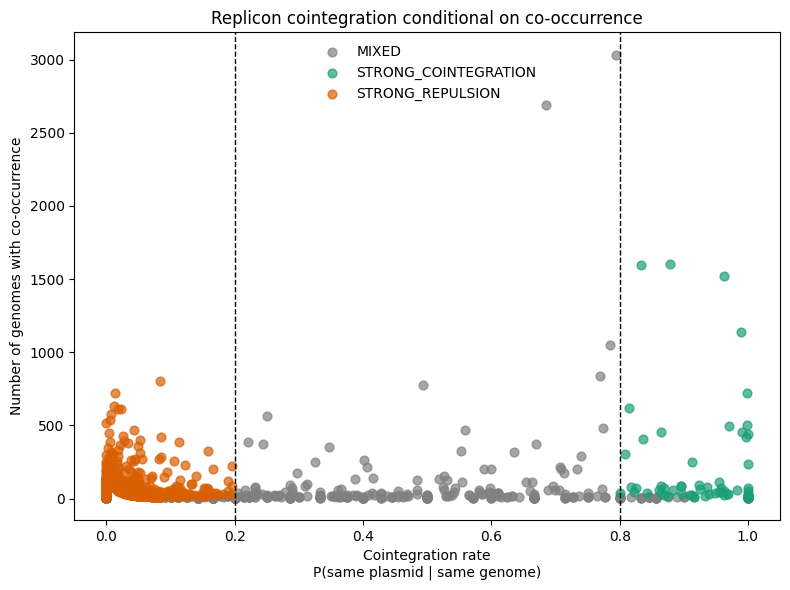

In [2]:
import pandas as pd
import numpy as np
import ast
from itertools import combinations
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportion_confint

# ============================================================
# 1. LOAD DATA
# ============================================================
nuccore  = pd.read_csv("meta/nuccore.csv")
assembly = pd.read_csv("meta/assembly.csv")
typing   = pd.read_csv("meta/typing.csv")

# ============================================================
# 2. ASSEMBLY → NUCCORE
# ============================================================
def safe_eval(x):
    if pd.isna(x):
        return []
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except Exception:
            return []
    return x

assembly["NUCCORE_UID"] = assembly["NUCCORE_UID"].apply(safe_eval)
assembly_long = (
    assembly
    .explode("NUCCORE_UID")
    .dropna(subset=["NUCCORE_UID"])
)

df = assembly_long.merge(
    nuccore[["NUCCORE_UID", "NUCCORE_ACC"]],
    on="NUCCORE_UID",
    how="left"
)

df = df.merge(
    typing[["NUCCORE_ACC", "rep_type(s)"]],
    on="NUCCORE_ACC",
    how="left"
)

# ============================================================
# 3. PARSE + EXPAND REPLICONS
# ============================================================
def parse_rep(x):
    if pd.isna(x):
        return []
    return [r.strip() for r in x.split(",") if r.strip()]

df["rep_types"] = df["rep_type(s)"].apply(parse_rep)

df_long = (
    df.explode("rep_types")
      .dropna(subset=["rep_types"])
      .reset_index(drop=True)
)

# ============================================================
# 4. CELL-LEVEL COINTEGRATION COUNTS
# ============================================================
records = {}

for cell, sub in df_long.groupby("ASSEMBLY_ACC"):

    plasmids = (
        sub.groupby("NUCCORE_ACC")["rep_types"]
        .apply(set)
        .to_dict()
    )

    if not plasmids:
        continue

    reps_in_cell = set.union(*plasmids.values())

    for a, b in combinations(sorted(reps_in_cell), 2):

        same_plasmid = any(
            {a, b}.issubset(reps)
            for reps in plasmids.values()
        )

        records.setdefault((a, b), []).append(int(same_plasmid))

# ============================================================
# 5. BUILD FINAL TABLE + BINOMIAL CI
# ============================================================
MIN_CELL = 5

rows = []
for (a, b), vals in records.items():
    n = len(vals)
    if n < MIN_CELL:
        continue

    k = sum(vals)
    p_hat = k / n

    ci_low, ci_high = proportion_confint(
        count=k,
        nobs=n,
        alpha=0.05,
        method="beta"   # exact Clopper–Pearson
    )

    rows.append({
        "repA": a,
        "repB": b,
        "n_same_cell": n,
        "n_cell_same_plasmid": k,
        "cointegration_rate": p_hat,
        "ci_low": ci_low,
        "ci_high": ci_high
    })

final = pd.DataFrame(rows)

# ============================================================
# 6. CLASSIFICATION (CONSISTENT LABELS)
# ============================================================
def classify(row):
    if row["cointegration_rate"] >= 0.8 and row["ci_low"] >= 0.6:
        return "STRONG_COINTEGRATION"
    elif row["cointegration_rate"] <= 0.2 and row["ci_high"] <= 0.4:
        return "STRONG_REPULSION"
    else:
        return "MIXED"

final["category"] = final.apply(classify, axis=1)

print(final["category"].value_counts())

# ============================================================
# 7. PLOT RESULTS (AXES FLIPPED)
# ============================================================
plt.figure(figsize=(8, 6))

colors = {
    "STRONG_COINTEGRATION": "#1b9e77",
    "STRONG_REPULSION": "#d95f02",
    "MIXED": "gray"
}

for cat, sub in final.groupby("category"):
    plt.scatter(
        sub["cointegration_rate"],   # X axis (flipped)
        sub["n_same_cell"],           # Y axis (flipped)
        s=40,
        alpha=0.7,
        label=cat,
        color=colors[cat]
    )

# Thresholds used in classification (now vertical lines)
plt.axvline(0.8, linestyle="--", color="black", linewidth=1)
plt.axvline(0.2, linestyle="--", color="black", linewidth=1)

plt.xlabel("Cointegration rate\nP(same plasmid | same genome)")
plt.ylabel("Number of genomes with co-occurrence")
plt.title("Replicon cointegration conditional on co-occurrence")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# ============================================================
# 8. EXPORT
# ============================================================
final.to_csv("replicon_cointegration_conditional.csv", index=False)



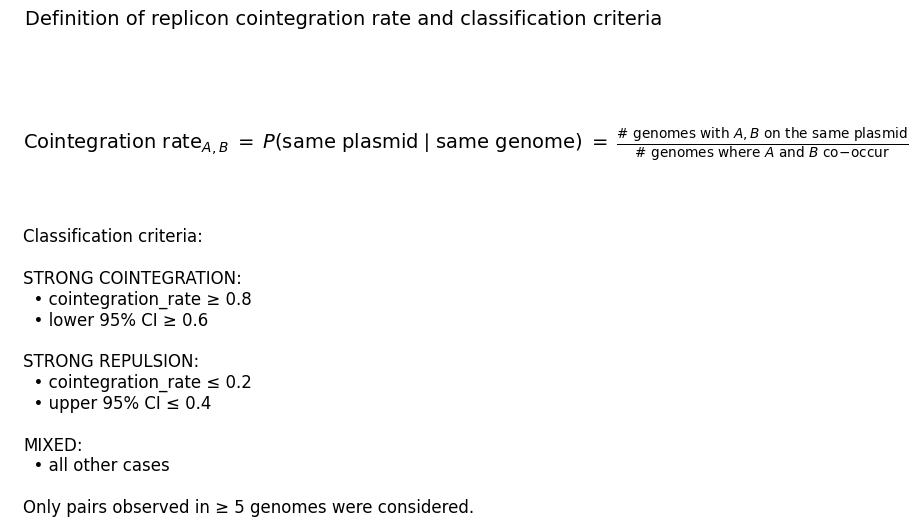

In [19]:
# ============================================================
# 9. EXPLANATORY FIGURE: FORMULA + CRITERIA
# ============================================================
plt.figure(figsize=(9, 5))
plt.axis("off")

formula_text = (
    r"$\mathrm{Cointegration\ rate}_{A,B}"
    r"\;=\;"
    r"P(\mathrm{same\ plasmid}\mid\mathrm{same\ genome})"
    r"\;=\;"
    r"\frac{\#\ \mathrm{genomes\ with}\ A,B\ \mathrm{on\ the\ same\ plasmid}}"
    r"{\#\ \mathrm{genomes\ where}\ A\ \mathrm{and}\ B\ \mathrm{co\!-\!occur}}$"
)

criteria_text = (
    "Classification criteria:\n\n"
    "STRONG COINTEGRATION:\n"
    "  • cointegration_rate ≥ 0.8\n"
    "  • lower 95% CI ≥ 0.6\n\n"
    "STRONG REPULSION:\n"
    "  • cointegration_rate ≤ 0.2\n"
    "  • upper 95% CI ≤ 0.4\n\n"
    "MIXED:\n"
    "  • all other cases\n\n"
    f"Only pairs observed in ≥ {MIN_CELL} genomes were considered."
)

plt.text(
    0.02, 0.75, formula_text,
    fontsize=14, va="top", ha="left"
)

plt.text(
    0.02, 0.40, criteria_text,
    fontsize=12, va="top", ha="left"
)

plt.title(
    "Definition of replicon cointegration rate and classification criteria",
    fontsize=14, pad=20
)

plt.tight_layout()
plt.show()


/tmp/ipykernel_574268/2701095976.py:165: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_variation)


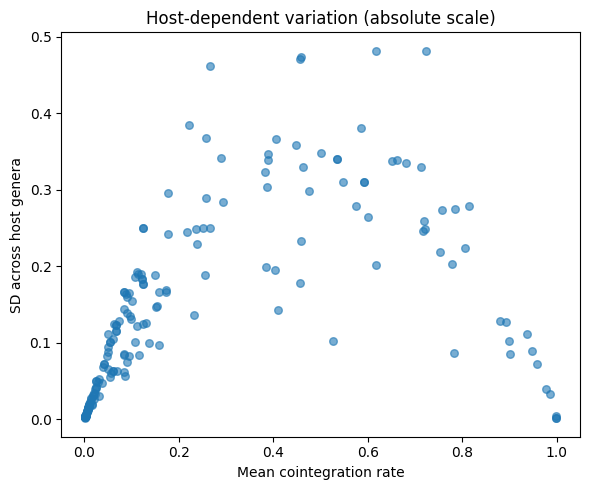

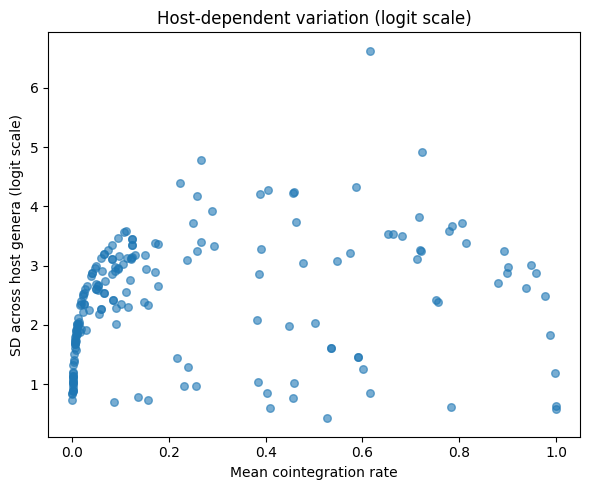

Spearman correlations (should NOT be ±1):
mean_p vs sd_p        : rho = 0.761, p = 5.866e-37
mean_p vs sd_logit_p  : rho = 0.427, p = 8.532e-10
Done.


In [26]:
# ============================================================
# HOST EFFECT (SCREENING, CORRECTED)
# Variación de cointegration por género del host
# ============================================================

import pandas as pd
import numpy as np
import ast
from itertools import combinations
from collections import defaultdict
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# ============================================================
# 1. LOAD DATA
# ============================================================

nuccore  = pd.read_csv("meta/nuccore.csv")
assembly = pd.read_csv("meta/assembly.csv")
typing   = pd.read_csv("meta/typing.csv")

# ============================================================
# 2. EXTRACT GENUS FROM NUCCORE DESCRIPTION
# ============================================================

nuccore["GENUS"] = (
    nuccore["NUCCORE_Description"]
    .astype(str)
    .str.strip()
    .str.split()
    .str[0]
    .str.capitalize()
)

# ============================================================
# 3. ASSEMBLY → NUCCORE
# ============================================================

def safe_eval(x):
    if pd.isna(x):
        return []
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except Exception:
            return []
    return x

assembly["NUCCORE_UID"] = assembly["NUCCORE_UID"].apply(safe_eval)

assembly_long = (
    assembly
    .explode("NUCCORE_UID")
    .dropna(subset=["NUCCORE_UID"])
)

df = assembly_long.merge(
    nuccore[["NUCCORE_UID", "NUCCORE_ACC", "GENUS"]],
    on="NUCCORE_UID",
    how="left"
)

df = df.merge(
    typing[["NUCCORE_ACC", "rep_type(s)"]],
    on="NUCCORE_ACC",
    how="left"
)

# ============================================================
# 4. PARSE + EXPAND REPLICONS
# ============================================================

def parse_rep(x):
    if pd.isna(x):
        return []
    return [r.strip() for r in x.split(",") if r.strip()]

df["rep_types"] = df["rep_type(s)"].apply(parse_rep)

df_long = (
    df.explode("rep_types")
      .dropna(subset=["rep_types", "GENUS"])
      .reset_index(drop=True)
)

# ============================================================
# 5. CELL-LEVEL COINTEGRATION COUNTS (BY GENUS)
# ============================================================

records = defaultdict(list)

for (assembly_acc, genus), sub in df_long.groupby(["ASSEMBLY_ACC", "GENUS"]):

    plasmids = (
        sub.groupby("NUCCORE_ACC")["rep_types"]
        .apply(set)
        .to_dict()
    )

    if not plasmids:
        continue

    reps_in_cell = set.union(*plasmids.values())

    for a, b in combinations(sorted(reps_in_cell), 2):

        same_plasmid = any(
            {a, b}.issubset(reps)
            for reps in plasmids.values()
        )

        records[(a, b, genus)].append(int(same_plasmid))

# ============================================================
# 6. BUILD p̂_g TABLE (PER GENUS)
# ============================================================

MIN_CELL_GENUS = 3
EPS = 1e-3

rows = []

for (a, b, genus), vals in records.items():

    n = len(vals)
    if n < MIN_CELL_GENUS:
        continue

    p_hat = sum(vals) / n

    rows.append({
        "repA": a,
        "repB": b,
        "genus": genus,
        "n_genomes": n,
        "cointegration_rate_genus": p_hat,
        "logit_p": np.log((p_hat + EPS) / (1 - p_hat + EPS))
    })

host_rates = pd.DataFrame(rows)

# ============================================================
# 7. VARIATION BETWEEN HOSTS (CORRECT METRICS)
# ============================================================

def summarize_variation(sub):
    p = sub["cointegration_rate_genus"].values
    z = sub["logit_p"].values

    return pd.Series({
        "n_genus": len(p),
        "mean_p": np.mean(p),

        # dispersion in probability space
        "sd_p": np.std(p, ddof=1) if len(p) > 1 else 0.0,
        "mad_p": np.median(np.abs(p - np.median(p))),

        # dispersion in unbounded space
        "sd_logit_p": np.std(z, ddof=1) if len(z) > 1 else 0.0
    })

host_variation = (
    host_rates
    .groupby(["repA", "repB"])
    .apply(summarize_variation)
    .reset_index()
)

# ============================================================
# 8. FILTER FOR INTERPRETABLE PAIRS
# ============================================================

host_variation = host_variation.query(
    "n_genus >= 3 and mean_p > 0"
)

# ============================================================
# 9. EXPORT
# ============================================================

host_rates.to_csv(
    "replicon_cointegration_by_genus.csv",
    index=False
)

host_variation.to_csv(
    "replicon_cointegration_host_variation_corrected.csv",
    index=False
)

# ============================================================
# 10. PLOTS + CORRELATIONS (NO ARTEFACTS)
# ============================================================

# Mean vs SD (probability space)
plt.figure(figsize=(6,5))
plt.scatter(host_variation["mean_p"], host_variation["sd_p"], s=30, alpha=0.6)
plt.xlabel("Mean cointegration rate")
plt.ylabel("SD across host genera")
plt.title("Host-dependent variation (absolute scale)")
plt.tight_layout()
plt.show()

# Mean vs SD in logit space
plt.figure(figsize=(6,5))
plt.scatter(host_variation["mean_p"], host_variation["sd_logit_p"], s=30, alpha=0.6)
plt.xlabel("Mean cointegration rate")
plt.ylabel("SD across host genera (logit scale)")
plt.title("Host-dependent variation (logit scale)")
plt.tight_layout()
plt.show()

# Correlations (Spearman, robust)
rho_sd, p_sd = spearmanr(
    host_variation["mean_p"],
    host_variation["sd_p"]
)

rho_logit, p_logit = spearmanr(
    host_variation["mean_p"],
    host_variation["sd_logit_p"]
)

print("Spearman correlations (should NOT be ±1):")
print(f"mean_p vs sd_p        : rho = {rho_sd:.3f}, p = {p_sd:.3e}")
print(f"mean_p vs sd_logit_p  : rho = {rho_logit:.3f}, p = {p_logit:.3e}")
print("Done.")


In [59]:
# ============================================================
# TABLE FOR PLOT 1: mean_p vs sd_p
# ============================================================

plot1_table = (
    host_variation[[
        "repA",
        "repB",
        "n_genus",
        "mean_p",
        "sd_p"
    ]]
    .sort_values("sd_p", ascending=False)
    .reset_index(drop=True)
)

plot1_table
plot1_table.to_csv(
    "replicon_host_effect_mean_vs_sd.csv",
    index=False
)


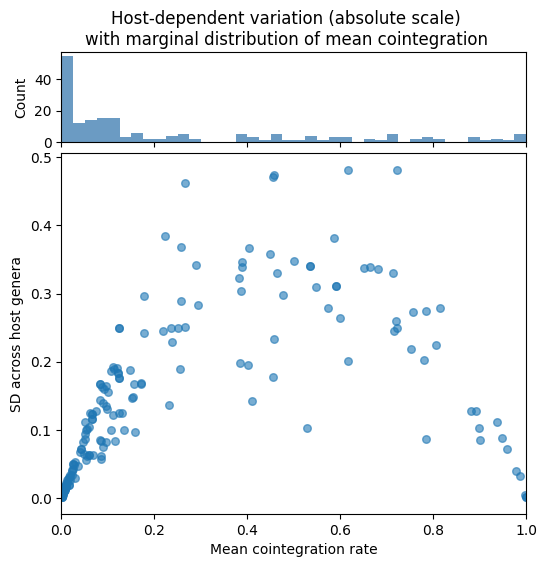

In [27]:
import matplotlib.gridspec as gridspec

# ============================================================
# Mean vs SD with marginal histogram (absolute scale)
# ============================================================

fig = plt.figure(figsize=(6,6))
gs = gridspec.GridSpec(
    2, 1,
    height_ratios=[1, 4],
    hspace=0.05
)

ax_hist = fig.add_subplot(gs[0])
ax_scatter = fig.add_subplot(gs[1], sharex=ax_hist)

# --- histogram (top)
ax_hist.hist(
    host_variation["mean_p"],
    bins=40,
    color="steelblue",
    alpha=0.8
)
ax_hist.set_ylabel("Count")
ax_hist.tick_params(axis="x", labelbottom=False)

# --- scatter (bottom)
ax_scatter.scatter(
    host_variation["mean_p"],
    host_variation["sd_p"],
    s=30,
    alpha=0.6
)

ax_scatter.set_xlabel("Mean cointegration rate")
ax_scatter.set_ylabel("SD across host genera")

ax_scatter.set_xlim(0, 1)

fig.suptitle(
    "Host-dependent variation (absolute scale)\nwith marginal distribution of mean cointegration",
    y=0.95
)

plt.show()


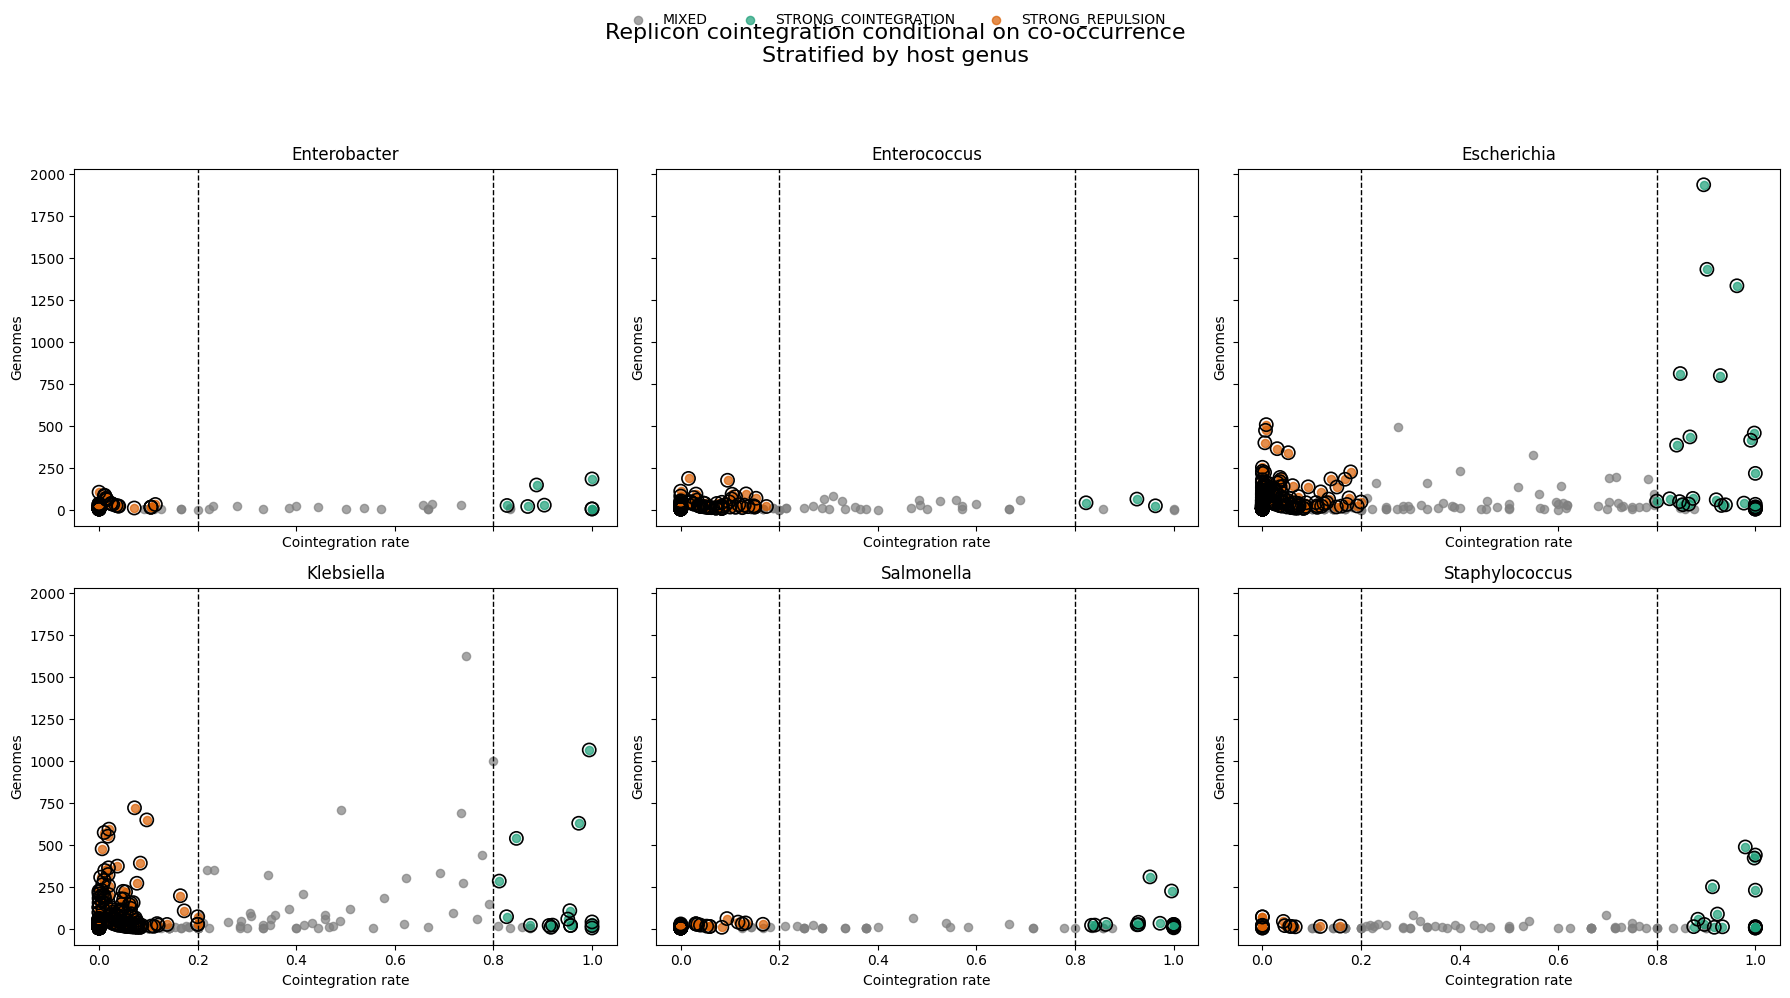

In [24]:
# ============================================================
# HOST-STRATIFIED REPLICON COINTEGRATION (6 MAIN GENERA)
# Same analysis as global, stratified by host genus
# ============================================================

import pandas as pd
import numpy as np
import ast
from itertools import combinations
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportion_confint

# ============================================================
# PARAMETERS
# ============================================================

TARGET_GENERA = {
    "Klebsiella",
    "Enterobacter",
    "Escherichia",
    "Staphylococcus",
    "Salmonella",
    "Enterococcus"
}

MIN_CELL = 5

colors = {
    "STRONG_COINTEGRATION": "#1b9e77",
    "STRONG_REPULSION": "#d95f02",
    "MIXED": "gray"
}

# ============================================================
# 1. LOAD DATA
# ============================================================

nuccore  = pd.read_csv("meta/nuccore.csv")
assembly = pd.read_csv("meta/assembly.csv")
typing   = pd.read_csv("meta/typing.csv")

# ============================================================
# 2. EXTRACT GENUS FROM NUCCORE DESCRIPTION
# ============================================================

nuccore["GENUS"] = (
    nuccore["NUCCORE_Description"]
    .astype(str)
    .str.strip()
    .str.split()
    .str[0]
    .str.capitalize()
)

# ============================================================
# 3. ASSEMBLY → NUCCORE
# ============================================================

def safe_eval(x):
    if pd.isna(x):
        return []
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except Exception:
            return []
    return x

assembly["NUCCORE_UID"] = assembly["NUCCORE_UID"].apply(safe_eval)

assembly_long = (
    assembly
    .explode("NUCCORE_UID")
    .dropna(subset=["NUCCORE_UID"])
)

df = assembly_long.merge(
    nuccore[["NUCCORE_UID", "NUCCORE_ACC", "GENUS"]],
    on="NUCCORE_UID",
    how="left"
)

df = df.merge(
    typing[["NUCCORE_ACC", "rep_type(s)"]],
    on="NUCCORE_ACC",
    how="left"
)

# ============================================================
# 4. PARSE + EXPAND REPLICONS
# ============================================================

def parse_rep(x):
    if pd.isna(x):
        return []
    return [r.strip() for r in x.split(",") if r.strip()]

df["rep_types"] = df["rep_type(s)"].apply(parse_rep)

df_long = (
    df.explode("rep_types")
      .dropna(subset=["rep_types", "GENUS"])
      .reset_index(drop=True)
)

# ============================================================
# 5. HOST-STRATIFIED COINTEGRATION ANALYSIS
# ============================================================

results_by_genus = {}

for genus in sorted(TARGET_GENERA):

    sub_df = df_long[df_long["GENUS"] == genus]

    records = {}

    for cell, sub in sub_df.groupby("ASSEMBLY_ACC"):

        plasmids = (
            sub.groupby("NUCCORE_ACC")["rep_types"]
            .apply(set)
            .to_dict()
        )

        if not plasmids:
            continue

        reps_in_cell = set.union(*plasmids.values())

        for a, b in combinations(sorted(reps_in_cell), 2):

            same_plasmid = any(
                {a, b}.issubset(reps)
                for reps in plasmids.values()
            )

            records.setdefault((a, b), []).append(int(same_plasmid))

    rows = []
    for (a, b), vals in records.items():

        n = len(vals)
        if n < MIN_CELL:
            continue

        k = sum(vals)
        p_hat = k / n

        ci_low, ci_high = proportion_confint(
            count=k,
            nobs=n,
            alpha=0.05,
            method="beta"
        )

        rows.append({
            "repA": a,
            "repB": b,
            "n_same_cell": n,
            "cointegration_rate": p_hat,
            "ci_low": ci_low,
            "ci_high": ci_high
        })

    genus_df = pd.DataFrame(rows)

    def classify(row):
        if row["cointegration_rate"] >= 0.8 and row["ci_low"] >= 0.6:
            return "STRONG_COINTEGRATION"
        elif row["cointegration_rate"] <= 0.2 and row["ci_high"] <= 0.4:
            return "STRONG_REPULSION"
        else:
            return "MIXED"

    if not genus_df.empty:
        genus_df["category"] = genus_df.apply(classify, axis=1)

    results_by_genus[genus] = genus_df

# ============================================================
# 6. PLOTTING (6 PANELS)
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, genus in zip(axes, sorted(TARGET_GENERA)):

    df_g = results_by_genus.get(genus)

    if df_g is None or df_g.empty:
        ax.set_title(f"{genus} (no data)")
        continue

    for cat, sub in df_g.groupby("category"):
        ax.scatter(
            sub["cointegration_rate"],
            sub["n_same_cell"],
            s=35,
            alpha=0.7,
            color=colors[cat],
            label=cat
        )

    # thresholds
    ax.axvline(0.8, linestyle="--", color="black", linewidth=1)
    ax.axvline(0.2, linestyle="--", color="black", linewidth=1)

    # highlight interesting pairs
    interesting = df_g[df_g["category"] != "MIXED"]
    ax.scatter(
        interesting["cointegration_rate"],
        interesting["n_same_cell"],
        s=90,
        facecolors="none",
        edgecolors="black",
        linewidths=1.2
    )

    ax.set_title(genus)
    ax.set_xlabel("Cointegration rate")
    ax.set_ylabel("Genomes")

# legend (once)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)

plt.suptitle(
    "Replicon cointegration conditional on co-occurrence\nStratified by host genus",
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()



In [58]:
# ============================================================
# 7. BUILD SUMMARY TABLE
# ============================================================

tables = []

for genus, df_g in results_by_genus.items():
    if df_g is None or df_g.empty:
        continue

    tmp = df_g.copy()
    tmp["genus"] = genus
    tables.append(tmp)

summary_table = (
    pd.concat(tables, ignore_index=True)
      .sort_values(
          by=["genus", "category", "cointegration_rate"],
          ascending=[True, True, False]
      )
)

summary_table
# ============================================================
# 8. EXPORT SUMMARY TABLE
# ============================================================

summary_table.to_csv(
    "replicon_cointegration_by_genus.csv",
    index=False
)


In [60]:
# ============================================================
# SUPPLEMENTARY TABLE – REPLICON COINTEGRATION
# Global + by genus + host variation (single export file)
# ============================================================

import pandas as pd
import numpy as np
import ast
from itertools import combinations
from collections import defaultdict
from statsmodels.stats.proportion import proportion_confint

# ------------------------------------------------------------
# PARAMETERS
# ------------------------------------------------------------

MIN_CELL_GLOBAL = 5
MIN_CELL_GENUS  = 3
TARGET_GENERA = {
    "Klebsiella",
    "Enterobacter",
    "Escherichia",
    "Staphylococcus",
    "Salmonella",
    "Enterococcus"
}
EPS = 1e-3

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------

nuccore  = pd.read_csv("meta/nuccore.csv")
assembly = pd.read_csv("meta/assembly.csv")
typing   = pd.read_csv("meta/typing.csv")

# ------------------------------------------------------------
# GENUS EXTRACTION
# ------------------------------------------------------------

nuccore["GENUS"] = (
    nuccore["NUCCORE_Description"]
    .astype(str)
    .str.strip()
    .str.split()
    .str[0]
    .str.capitalize()
)

# ------------------------------------------------------------
# ASSEMBLY → NUCCORE
# ------------------------------------------------------------

def safe_eval(x):
    if pd.isna(x):
        return []
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except Exception:
            return []
    return x

assembly["NUCCORE_UID"] = assembly["NUCCORE_UID"].apply(safe_eval)

assembly_long = (
    assembly
    .explode("NUCCORE_UID")
    .dropna(subset=["NUCCORE_UID"])
)

df = assembly_long.merge(
    nuccore[["NUCCORE_UID", "NUCCORE_ACC", "GENUS"]],
    on="NUCCORE_UID",
    how="left"
)

df = df.merge(
    typing[["NUCCORE_ACC", "rep_type(s)"]],
    on="NUCCORE_ACC",
    how="left"
)

def parse_rep(x):
    if pd.isna(x):
        return []
    return [r.strip() for r in x.split(",") if r.strip()]

df["rep_types"] = df["rep_type(s)"].apply(parse_rep)

df_long = (
    df.explode("rep_types")
      .dropna(subset=["rep_types"])
      .reset_index(drop=True)
)

# ============================================================
# 1) GLOBAL COINTEGRATION
# ============================================================

records_global = defaultdict(list)

for assembly_acc, sub in df_long.groupby("ASSEMBLY_ACC"):

    plasmids = (
        sub.groupby("NUCCORE_ACC")["rep_types"]
        .apply(set)
        .to_dict()
    )

    if not plasmids:
        continue

    reps = set.union(*plasmids.values())

    for a, b in combinations(sorted(reps), 2):

        same = any({a, b}.issubset(r) for r in plasmids.values())
        records_global[(a, b)].append(int(same))

rows = []
for (a, b), vals in records_global.items():

    n = len(vals)
    if n < MIN_CELL_GLOBAL:
        continue

    k = sum(vals)
    p = k / n

    ci_low, ci_high = proportion_confint(
        count=k,
        nobs=n,
        alpha=0.05,
        method="beta"
    )

    rows.append({
        "repA": a,
        "repB": b,
        "n_genomes_cooccurrence": n,
        "n_same_plasmid": k,
        "cointegration_efficiency": p,
        "ci_low_95": ci_low,
        "ci_high_95": ci_high
    })

global_df = pd.DataFrame(rows)

def classify(row):
    if row["cointegration_efficiency"] >= 0.8 and row["ci_low_95"] >= 0.6:
        return "STRONG_COINTEGRATION"
    elif row["cointegration_efficiency"] <= 0.2 and row["ci_high_95"] <= 0.4:
        return "STRONG_REPULSION"
    else:
        return "MIXED"

global_df["classification"] = global_df.apply(classify, axis=1)

summary_counts = (
    global_df["classification"]
    .value_counts()
    .rename_axis("classification")
    .reset_index(name="n_pairs")
)

total_pairs = summary_counts["n_pairs"].sum()
summary_counts["percent"] = summary_counts["n_pairs"] / total_pairs * 100

# ============================================================
# 2) BY GENUS
# ============================================================

records_genus = defaultdict(list)

for (assembly_acc, genus), sub in df_long.groupby(["ASSEMBLY_ACC", "GENUS"]):

    if genus not in TARGET_GENERA:
        continue

    plasmids = (
        sub.groupby("NUCCORE_ACC")["rep_types"]
        .apply(set)
        .to_dict()
    )

    if not plasmids:
        continue

    reps = set.union(*plasmids.values())

    for a, b in combinations(sorted(reps), 2):

        same = any({a, b}.issubset(r) for r in plasmids.values())
        records_genus[(a, b, genus)].append(int(same))

rows = []
for (a, b, genus), vals in records_genus.items():

    n = len(vals)
    if n < MIN_CELL_GENUS:
        continue

    k = sum(vals)
    p = k / n

    ci_low, ci_high = proportion_confint(
        count=k,
        nobs=n,
        alpha=0.05,
        method="beta"
    )

    rows.append({
        "repA": a,
        "repB": b,
        "genus": genus,
        "n_genomes_cooccurrence": n,
        "cointegration_efficiency": p,
        "ci_low_95": ci_low,
        "ci_high_95": ci_high
    })

genus_df = pd.DataFrame(rows)

if not genus_df.empty:
    genus_df["classification"] = genus_df.apply(classify, axis=1)

# ============================================================
# 3) HOST VARIATION
# ============================================================

rows = []

for (a, b), sub in genus_df.groupby(["repA", "repB"]):

    p_vals = sub["cointegration_efficiency"].values
    z_vals = np.log((p_vals + EPS) / (1 - p_vals + EPS))

    rows.append({
        "repA": a,
        "repB": b,
        "n_host_genera": len(p_vals),
        "mean_cointegration_efficiency": np.mean(p_vals),
        "sd_probability_space": np.std(p_vals, ddof=1) if len(p_vals)>1 else 0,
        "mad_probability_space": np.median(np.abs(p_vals - np.median(p_vals))),
        "sd_logit_space": np.std(z_vals, ddof=1) if len(z_vals)>1 else 0
    })

host_variation_df = pd.DataFrame(rows)

# ============================================================
# EXPORT SINGLE SUPPLEMENTARY FILE
# ============================================================

with pd.ExcelWriter("Supplementary_Table_Replicon_Cointegration.xlsx") as writer:

    global_df.to_excel(writer,
        sheet_name="Global_cointegration_estimates",
        index=False)

    summary_counts.to_excel(writer,
        sheet_name="Global_summary_counts",
        index=False)

    genus_df.to_excel(writer,
        sheet_name="Cointegration_by_genus",
        index=False)

    host_variation_df.to_excel(writer,
        sheet_name="Host_dependence_variation",
        index=False)

print("Supplementary table exported successfully.")


Supplementary table exported successfully.


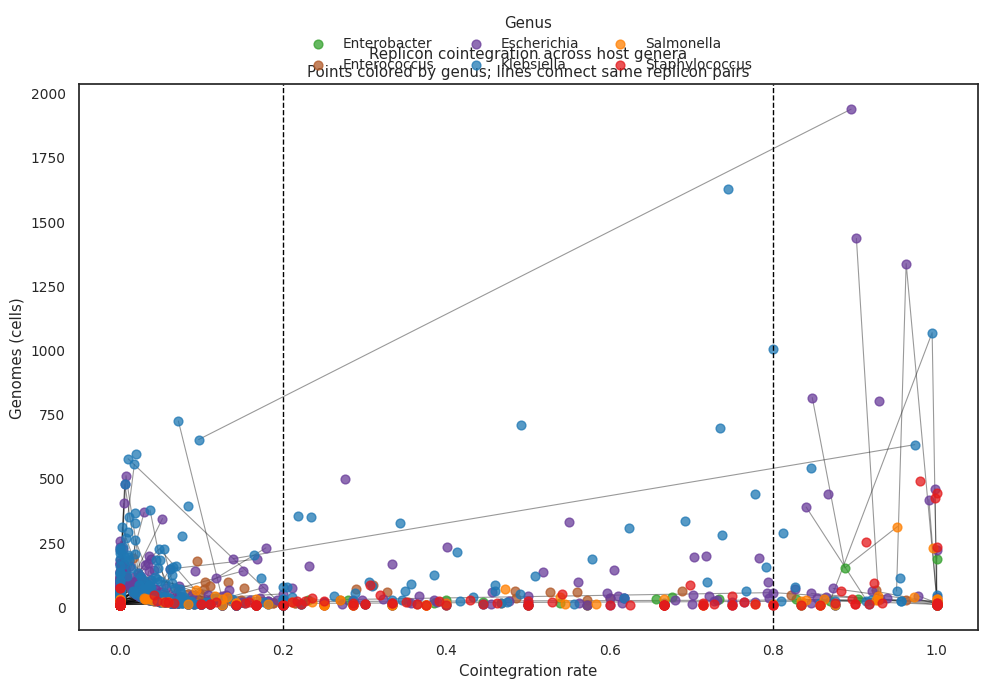

In [43]:
# ============================================================
# 6. SINGLE-PANEL PLOT (color by genus + lines by replicon pair)
# ============================================================

# ------------------------------------------------------------
# 6.1 Concatenate results
# ------------------------------------------------------------
dfs = []
for genus, gdf in results_by_genus.items():
    if gdf is None or gdf.empty:
        continue
    tmp = gdf.copy()
    tmp["GENUS"] = genus
    tmp["pair_id"] = tmp.apply(
        lambda r: "|".join(sorted([r["repA"], r["repB"]])),
        axis=1
    )
    dfs.append(tmp)

plot_df = pd.concat(dfs, ignore_index=True)

# ------------------------------------------------------------
# 6.2 Color map by genus
# ------------------------------------------------------------
genus_colors = {
    "Klebsiella":    "#1f78b4",
    "Enterobacter":  "#33a02c",
    "Escherichia":   "#6a3d9a",
    "Staphylococcus":"#e31a1c",
    "Salmonella":   "#ff7f00",
    "Enterococcus": "#b15928",
}

# ------------------------------------------------------------
# 6.3 Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 7))

# --- scatter by genus
for genus, sub in plot_df.groupby("GENUS"):
    ax.scatter(
        sub["cointegration_rate"],
        sub["n_same_cell"],
        s=40,
        alpha=0.75,
        color=genus_colors.get(genus, "gray"),
        label=genus
    )

# --- lines connecting same replicon pairs across genera
for pair_id, sub in plot_df.groupby("pair_id"):

    if len(sub) < 2:
        continue

    # optional: only connect strong signals to reduce clutter
    sub = sub[sub["category"] != "MIXED"]
    if len(sub) < 2:
        continue

    sub = sub.sort_values("cointegration_rate")

    ax.plot(
        sub["cointegration_rate"],
        sub["n_same_cell"],
        color="black",
        linewidth=0.8,
        alpha=0.4,
        zorder=0
    )

# ------------------------------------------------------------
# 6.4 Thresholds & styling
# ------------------------------------------------------------
ax.axvline(0.8, linestyle="--", color="black", linewidth=1)
ax.axvline(0.2, linestyle="--", color="black", linewidth=1)

ax.set_xlabel("Cointegration rate")
ax.set_ylabel("Genomes (cells)")
ax.set_title(
    "Replicon cointegration across host genera\n"
    "Points colored by genus; lines connect same replicon pairs"
)

ax.legend(
    title="Genus",
    frameon=False,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.15)
)

plt.tight_layout()
plt.show()


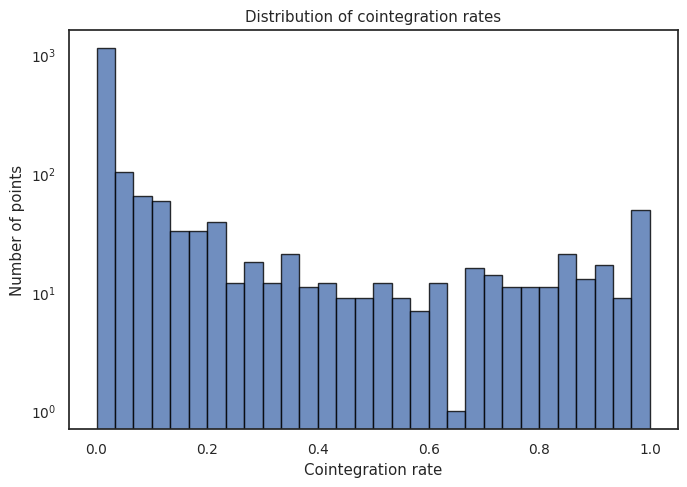

In [47]:
# ============================================================
# HISTOGRAM: cointegration rate (counts)
# ============================================================

fig, ax = plt.subplots(figsize=(7, 5))

ax.hist(
    plot_df["cointegration_rate"],
    bins=30,
    edgecolor="black",
    alpha=0.8
)

ax.set_xlabel("Cointegration rate")
ax.set_ylabel("Number of points")
ax.set_yscale("log")
ax.set_title("Distribution of cointegration rates")

plt.tight_layout()
plt.show()


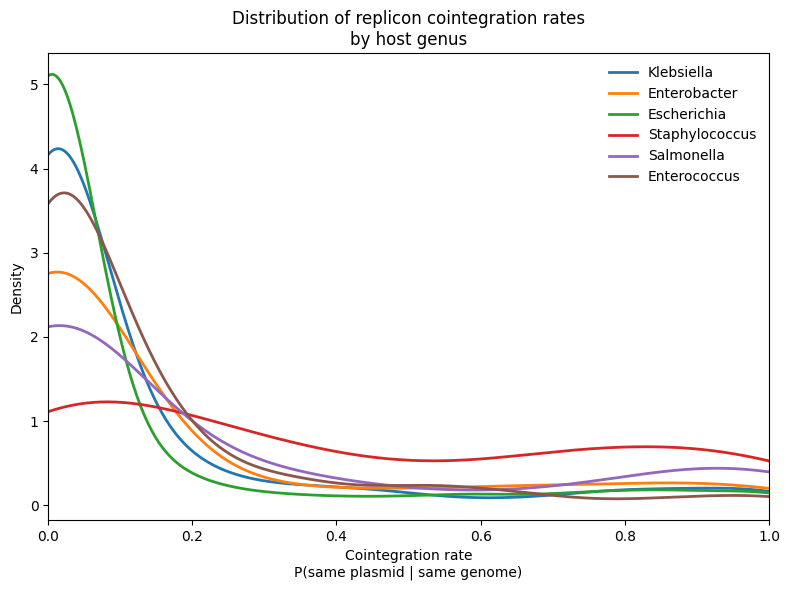

Klebsiella       median=0.000  n_pairs=472
Enterobacter     median=0.000  n_pairs=123
Escherichia      median=0.000  n_pairs=712
Staphylococcus   median=0.293  n_pairs=122
Salmonella       median=0.000  n_pairs=157
Enterococcus     median=0.026  n_pairs=196


In [25]:
# ============================================================
# DENSITY PLOTS OF COINTEGRATION RATE
# For the 6 main host genera
# ============================================================

import pandas as pd
import numpy as np
import ast
from itertools import combinations
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportion_confint
from scipy.stats import gaussian_kde

# ============================================================
# PARAMETERS
# ============================================================

TARGET_GENERA = [
    "Klebsiella",
    "Enterobacter",
    "Escherichia",
    "Staphylococcus",
    "Salmonella",
    "Enterococcus"
]

MIN_CELL = 5
GRID = np.linspace(0, 1, 400)

# ============================================================
# 1. RECOMPUTE COINTEGRATION PER GENUS (same logic as before)
# ============================================================

records_by_genus = {g: {} for g in TARGET_GENERA}

for genus in TARGET_GENERA:

    sub_df = df_long[df_long["GENUS"] == genus]

    for cell, sub in sub_df.groupby("ASSEMBLY_ACC"):

        plasmids = (
            sub.groupby("NUCCORE_ACC")["rep_types"]
            .apply(set)
            .to_dict()
        )

        if not plasmids:
            continue

        reps_in_cell = set.union(*plasmids.values())

        for a, b in combinations(sorted(reps_in_cell), 2):

            same_plasmid = any(
                {a, b}.issubset(reps)
                for reps in plasmids.values()
            )

            records_by_genus[genus].setdefault((a, b), []).append(
                int(same_plasmid)
            )

# ============================================================
# 2. COLLECT COINTEGRATION RATES
# ============================================================

rates = {}

for genus, records in records_by_genus.items():

    vals = []

    for (a, b), xs in records.items():
        if len(xs) >= MIN_CELL:
            vals.append(sum(xs) / len(xs))

    rates[genus] = np.array(vals)

# ============================================================
# 3. PLOT KDEs
# ============================================================

plt.figure(figsize=(8,6))

for genus, vals in rates.items():

    if len(vals) < 10:
        continue  # avoid degenerate KDEs

    kde = gaussian_kde(vals, bw_method="scott")
    plt.plot(GRID, kde(GRID), label=genus, linewidth=2)

plt.xlabel("Cointegration rate\nP(same plasmid | same genome)")
plt.ylabel("Density")
plt.title("Distribution of replicon cointegration rates\nby host genus")

plt.xlim(0, 1)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# ============================================================
# 4. OPTIONAL: MEDIANS FOR CONTEXT
# ============================================================

for genus, vals in rates.items():
    if len(vals) > 0:
        print(
            f"{genus:15s}  median={np.median(vals):.3f}  n_pairs={len(vals)}"
        )


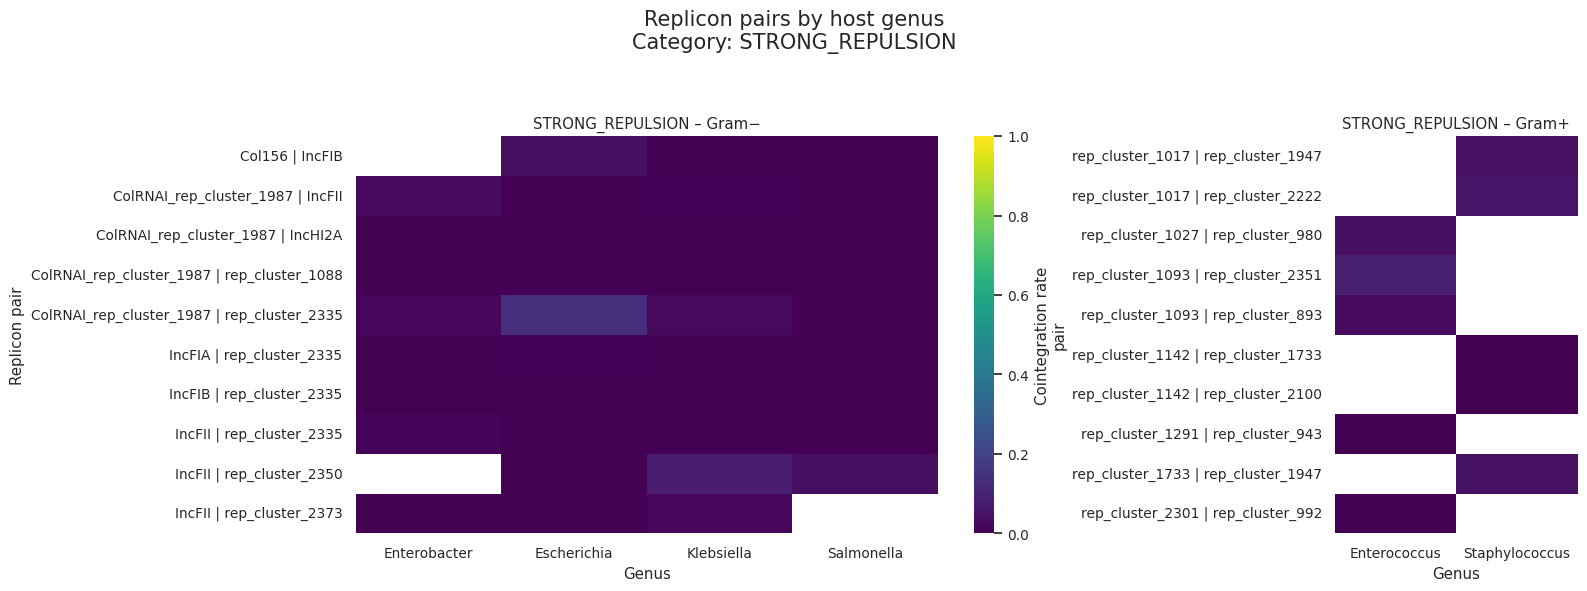

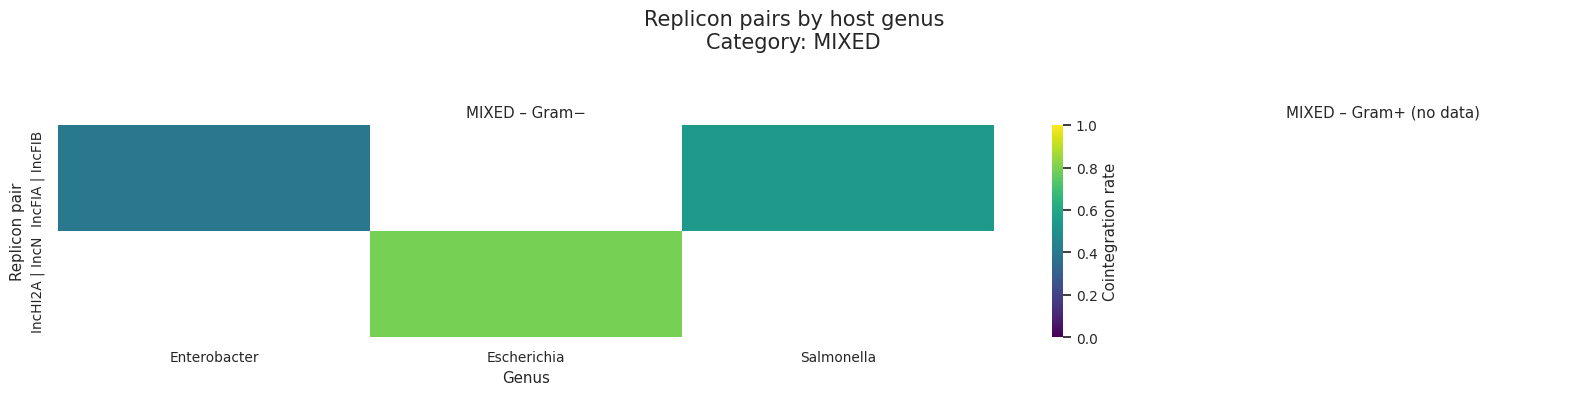

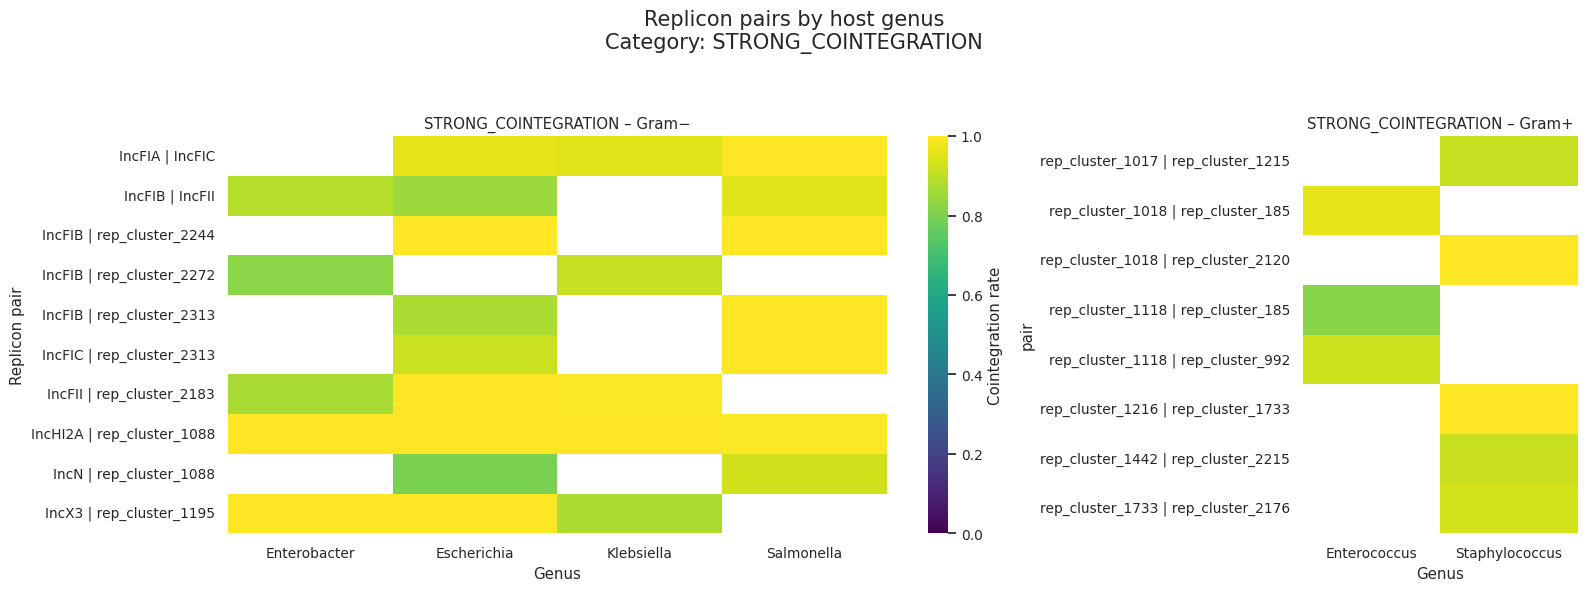

In [55]:
# ============================================================
# HEATMAPS BY CATEGORY × GRAM STATUS
# MIXED = ONLY opposite-behaviour pairs (NO further filtering)
# AUTOCONTENIDO (CORREGIDO DEFINITIVO)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

GRAM_POS = {"Enterococcus", "Staphylococcus"}
GRAM_NEG = set(TARGET_GENERA) - GRAM_POS

CATEGORIES = [
    "STRONG_REPULSION",
    "MIXED",
    "STRONG_COINTEGRATION"
]

sns.set(style="white", font_scale=0.9)

# ------------------------------------------------------------
# 1. COMBINE results_by_genus INTO ONE DF
# ------------------------------------------------------------

dfs = []
for genus, df_g in results_by_genus.items():
    if df_g is None or df_g.empty:
        continue
    tmp = df_g.copy()
    tmp["GENUS"] = genus
    tmp["pair"] = tmp["repA"] + " | " + tmp["repB"]
    dfs.append(tmp)

all_df = pd.concat(dfs, ignore_index=True)

# ------------------------------------------------------------
# 2. IDENTIFY SIGNIFICANT MIXED PAIRS
# ------------------------------------------------------------

pair_genus_cat = defaultdict(set)

for _, r in all_df.iterrows():
    pair_genus_cat[r["pair"]].add(r["category"])

mixed_significant_pairs = {
    pair for pair, cats in pair_genus_cat.items()
    if "STRONG_COINTEGRATION" in cats and "STRONG_REPULSION" in cats
}

# ------------------------------------------------------------
# 3. SELECTION FUNCTIONS (ONLY FOR STRONG_*)
# ------------------------------------------------------------

def select_max_genus(df_sub):
    if df_sub.empty:
        return set()
    rank = (
        df_sub.groupby("pair")["GENUS"]
        .nunique()
        .reset_index(name="n_genus")
        .sort_values("n_genus", ascending=False)
    )
    n_keep = 10 if len(rank) >= 10 else min(5, len(rank))
    return set(rank.head(n_keep)["pair"])


def select_gram_pos_strong(df_sub):
    """
    Gram+ STRONG_*:
    - prefer pairs present in BOTH genera
    - fallback: 5 + 5 exclusives
    """
    if df_sub.empty:
        return set()

    genus_count = (
        df_sub.groupby("pair")["GENUS"]
        .nunique()
        .reset_index(name="n_genus")
    )

    shared = genus_count[genus_count["n_genus"] == 2]["pair"]

    if len(shared) >= 10:
        return set(shared.head(10))

    selected = set(shared)

    for g in GRAM_POS:
        g_pairs = (
            df_sub[df_sub["GENUS"] == g]["pair"]
            .value_counts()
            .head(5)
            .index
        )
        selected.update(g_pairs)

    return set(list(selected)[:10])

# ------------------------------------------------------------
# 4. HEATMAPS
# ------------------------------------------------------------

for cat in CATEGORIES:

    df_cat = all_df[all_df["category"] == cat]

    if cat == "MIXED":
        # 🔑 KEY FIX: use ALL significant mixed pairs, no further filtering
        df_cat = df_cat[df_cat["pair"].isin(mixed_significant_pairs)]

    if df_cat.empty:
        continue

    df_neg = df_cat[df_cat["GENUS"].isin(GRAM_NEG)]
    df_pos = df_cat[df_cat["GENUS"].isin(GRAM_POS)]

    if cat in {"STRONG_REPULSION", "STRONG_COINTEGRATION"}:
        top_neg = select_max_genus(df_neg)
        top_pos = select_gram_pos_strong(df_pos)
    else:
        # MIXED: keep everything
        top_neg = set(df_neg["pair"].unique())
        top_pos = set(df_pos["pair"].unique())

    def build_matrix(df_sub, genera, keep):
        if not keep:
            return pd.DataFrame()
        return (
            df_sub[
                (df_sub["GENUS"].isin(genera)) &
                (df_sub["pair"].isin(keep))
            ]
            .pivot_table(
                index="pair",
                columns="GENUS",
                values="cointegration_rate",
                aggfunc="mean"
            )
        )

    mat_neg = build_matrix(df_cat, GRAM_NEG, top_neg)
    mat_pos = build_matrix(df_cat, GRAM_POS, top_pos)

    fig, axes = plt.subplots(
        1, 2,
        figsize=(16, max(4, 0.6 * max(len(mat_neg), len(mat_pos)))),
        gridspec_kw={"width_ratios": [3, 1]},
        sharey=False
    )

    # Gram −
    if not mat_neg.empty:
        sns.heatmap(
            mat_neg,
            ax=axes[0],
            cmap="viridis",
            vmin=0,
            vmax=1,
            cbar=True,
            cbar_kws={"label": "Cointegration rate"}
        )
        axes[0].set_title(f"{cat} – Gram−")
        axes[0].set_xlabel("Genus")
        axes[0].set_ylabel("Replicon pair")
    else:
        axes[0].set_title(f"{cat} – Gram− (no data)")
        axes[0].axis("off")

    # Gram +
    if not mat_pos.empty:
        sns.heatmap(
            mat_pos,
            ax=axes[1],
            cmap="viridis",
            vmin=0,
            vmax=1,
            cbar=False
        )
        axes[1].set_title(f"{cat} – Gram+")
        axes[1].set_xlabel("Genus")
    else:
        axes[1].set_title(f"{cat} – Gram+ (no data)")
        axes[1].axis("off")

    plt.suptitle(
        f"Replicon pairs by host genus\nCategory: {cat}",
        fontsize=15
    )

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


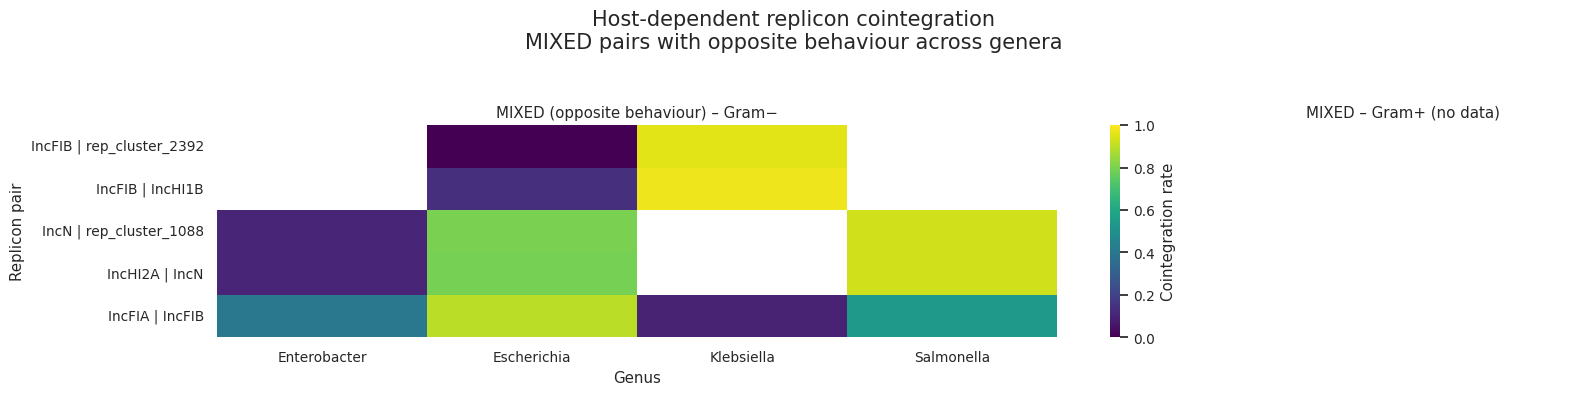

In [56]:
# ============================================================
# HEATMAP FOR MIXED (OPPOSITE-BEHAVIOUR PAIRS)
# Single heatmap per Gram group
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

sns.set(style="white", font_scale=0.9)

GRAM_POS = {"Enterococcus", "Staphylococcus"}
GRAM_NEG = set(TARGET_GENERA) - GRAM_POS

# ------------------------------------------------------------
# 1. BUILD GLOBAL TABLE
# ------------------------------------------------------------

rows = []
for genus, df_g in results_by_genus.items():
    if df_g is None or df_g.empty:
        continue
    for _, r in df_g.iterrows():
        rows.append({
            "pair": f"{r['repA']} | {r['repB']}",
            "GENUS": genus,
            "category": r["category"],
            "cointegration_rate": r["cointegration_rate"]
        })

all_df = pd.DataFrame(rows)

# ------------------------------------------------------------
# 2. IDENTIFY SIGNIFICANT MIXED PAIRS
# ------------------------------------------------------------

pair_cats = all_df.groupby("pair")["category"].apply(set)

mixed_pairs = pair_cats[
    pair_cats.apply(
        lambda s: (
            "STRONG_COINTEGRATION" in s and
            "STRONG_REPULSION" in s
        )
    )
].index

mixed_df = all_df[
    (all_df["pair"].isin(mixed_pairs))
]

# ------------------------------------------------------------
# 3. BUILD HEATMAP MATRICES
# ------------------------------------------------------------

def build_heatmap(df_sub, genera):
    mat = (
        df_sub[df_sub["GENUS"].isin(genera)]
        .pivot_table(
            index="pair",
            columns="GENUS",
            values="cointegration_rate",
            aggfunc="mean"
        )
    )

    # order rows by max-min (strength of switch)
    delta = mat.max(axis=1) - mat.min(axis=1)
    mat = mat.loc[delta.sort_values(ascending=False).index]

    return mat

mat_neg = build_heatmap(mixed_df, GRAM_NEG)
mat_pos = build_heatmap(mixed_df, GRAM_POS)

# ------------------------------------------------------------
# 4. PLOT
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, max(4, 0.6 * max(len(mat_neg), len(mat_pos)))),
    gridspec_kw={"width_ratios": [3, 1]},
    sharey=False
)

# Gram −
if not mat_neg.empty:
    sns.heatmap(
        mat_neg,
        ax=axes[0],
        cmap="viridis",
        vmin=0,
        vmax=1,
        cbar=True,
        cbar_kws={"label": "Cointegration rate"}
    )
    axes[0].set_title("MIXED (opposite behaviour) – Gram−")
    axes[0].set_xlabel("Genus")
    axes[0].set_ylabel("Replicon pair")
else:
    axes[0].set_title("MIXED – Gram− (no data)")
    axes[0].axis("off")

# Gram +
if not mat_pos.empty:
    sns.heatmap(
        mat_pos,
        ax=axes[1],
        cmap="viridis",
        vmin=0,
        vmax=1,
        cbar=False
    )
    axes[1].set_title("MIXED (opposite behaviour) – Gram+")
    axes[1].set_xlabel("Genus")
else:
    axes[1].set_title("MIXED – Gram+ (no data)")
    axes[1].axis("off")

plt.suptitle(
    "Host-dependent replicon cointegration\nMIXED pairs with opposite behaviour across genera",
    fontsize=15
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


In [57]:
# ============================================================
# SINGLE TABLE WITH ALL RELEVANT REPLICON PAIRS
# (STRONG_* + MIXED opposite-behaviour)
# ============================================================

import pandas as pd
from collections import defaultdict

# ------------------------------------------------------------
# 1. BUILD FULL LONG TABLE (pair × genus)
# ------------------------------------------------------------

rows = []

for genus, df_g in results_by_genus.items():
    if df_g is None or df_g.empty:
        continue

    for _, r in df_g.iterrows():
        rows.append({
            "pair": f"{r['repA']} | {r['repB']}",
            "repA": r["repA"],
            "repB": r["repB"],
            "GENUS": genus,
            "category": r["category"],
            "cointegration_rate": r["cointegration_rate"],
            "ci_low": r["ci_low"],
            "ci_high": r["ci_high"],
            "n_same_cell": r["n_same_cell"]
        })

all_pairs_df = pd.DataFrame(rows)

# ------------------------------------------------------------
# 2. IDENTIFY MIXED OPPOSITE-BEHAVIOUR PAIRS (GLOBAL)
# ------------------------------------------------------------

pair_to_cats = (
    all_pairs_df
    .groupby("pair")["category"]
    .apply(set)
)

mixed_opposite_pairs = set(
    pair_to_cats[
        pair_to_cats.apply(
            lambda s: (
                "STRONG_COINTEGRATION" in s and
                "STRONG_REPULSION" in s
            )
        )
    ].index
)

all_pairs_df["is_mixed_opposite"] = (
    all_pairs_df["pair"].isin(mixed_opposite_pairs)
)

# ------------------------------------------------------------
# 3. IDENTIFY PAIRS USED IN STRONG HEATMAPS
#    (presence in ≥1 genus as STRONG_*)
# ------------------------------------------------------------

strong_pairs = set(
    all_pairs_df[
        all_pairs_df["category"].isin(
            ["STRONG_COINTEGRATION", "STRONG_REPULSION"]
        )
    ]["pair"]
)

# ------------------------------------------------------------
# 4. FINAL TABLE: UNION OF ALL RELEVANT PAIRS
# ------------------------------------------------------------

final_table = all_pairs_df[
    (all_pairs_df["pair"].isin(strong_pairs)) |
    (all_pairs_df["is_mixed_opposite"])
].sort_values(
    ["pair", "GENUS"]
)

# ------------------------------------------------------------
# 5. SUMMARY
# ------------------------------------------------------------

print("Summary of final table")
print("----------------------")
print("Total rows (pair × genus):", len(final_table))
print("Unique pairs:", final_table["pair"].nunique())
print("  STRONG pairs:",
      final_table[
          final_table["category"].isin(
              ["STRONG_COINTEGRATION", "STRONG_REPULSION"]
          )
      ]["pair"].nunique()
)
print("  MIXED opposite pairs:",
      final_table[
          final_table["is_mixed_opposite"]
      ]["pair"].nunique()
)

# ------------------------------------------------------------
# 6. EXPORT
# ------------------------------------------------------------

final_table.to_csv(
    "replicon_pairs_all_heatmaps_table.csv",
    index=False
)

final_table.head(20)


Summary of final table
----------------------
Total rows (pair × genus): 1254
Unique pairs: 825
  STRONG pairs: 825
  MIXED opposite pairs: 5


,pair,repA,repB,GENUS,category,cointegration_rate,ci_low,ci_high,n_same_cell,is_mixed_opposite
439,Col(BS512) | Col(MG828),Col(BS512),Col(MG828),Escherichia,STRONG_REPULSION,0.000000,0.000000,0.075486,47,False
440,Col(BS512) | Col156,Col(BS512),Col156,Escherichia,STRONG_REPULSION,0.000000,0.000000,0.094891,37,False
441,Col(BS512) | ColRNAI_rep_cluster_1987,Col(BS512),ColRNAI_rep_cluster_1987,Escherichia,STRONG_REPULSION,0.000000,0.000000,0.205907,16,False
1345,Col(BS512) | ColRNAI_rep_cluster_1987,Col(BS512),ColRNAI_rep_cluster_1987,Klebsiella,STRONG_REPULSION,0.000000,0.000000,0.264648,12,False
512,Col(BS512) | ColpVC,Col(BS512),ColpVC,Escherichia,STRONG_REPULSION,0.000000,0.000000,0.308497,10,False
442,Col(BS512) | IncFIA,Col(BS512),IncFIA,Escherichia,STRONG_REPULSION,0.000000,0.000000,0.036217,100,False
1401,Col(BS512) | IncFIA,Col(BS512),IncFIA,Klebsiella,MIXED,0.000000,0.000000,0.409616,7,False
411,Col(BS512) | IncFIB,Col(BS512),IncFIB,Escherichia,STRONG_REPULSION,0.008264,0.000209,0.045186,121,False
1346,Col(BS512) | IncFIB,Col(BS512),IncFIB,Klebsiella,STRONG_REPULSION,0.000000,0.000000,0.247053,13,False
443,Col(BS512) | IncFIC,Col(BS512),IncFIC,Escherichia,STRONG_REPULSION,0.000000,0.000000,0.062667,57,False


In [52]:
import pandas as pd
from collections import defaultdict

# ============================================================
# FIND PAIRS WITH STRONG_COINTEGRATION IN ONE GENUS
# AND STRONG_REPULSION IN ANOTHER
# ============================================================

rows = []

for genus, df_g in results_by_genus.items():
    if df_g is None or df_g.empty:
        continue

    for _, r in df_g.iterrows():
        rows.append({
            "pair": f"{r['repA']} | {r['repB']}",
            "repA": r["repA"],
            "repB": r["repB"],
            "GENUS": genus,
            "category": r["category"],
            "cointegration_rate": r["cointegration_rate"],
            "ci_low": r["ci_low"],
            "ci_high": r["ci_high"],
            "n_same_cell": r["n_same_cell"]
        })

all_pairs = pd.DataFrame(rows)

# ------------------------------------------------------------
# group by pair and check opposite categories
# ------------------------------------------------------------

pair_categories = (
    all_pairs
    .groupby("pair")["category"]
    .apply(set)
)

# pairs with opposite strong behavior
opposite_pairs = pair_categories[
    pair_categories.apply(
        lambda s: (
            "STRONG_COINTEGRATION" in s and
            "STRONG_REPULSION" in s
        )
    )
].index

# ------------------------------------------------------------
# final table: values per genus
# ------------------------------------------------------------

opposite_df = all_pairs[
    all_pairs["pair"].isin(opposite_pairs)
].sort_values(
    ["pair", "GENUS"]
)

print(f"Number of opposite-behavior pairs: {len(opposite_pairs)}")
opposite_df


Number of opposite-behavior pairs: 5


,pair,repA,repB,GENUS,category,cointegration_rate,ci_low,ci_high,n_same_cell
18,IncFIA | IncFIB,IncFIA,IncFIB,Enterobacter,MIXED,0.400000,0.211255,0.613347,25
319,IncFIA | IncFIB,IncFIA,IncFIB,Escherichia,STRONG_COINTEGRATION,0.895199,0.880697,0.908491,1937
1038,IncFIA | IncFIB,IncFIA,IncFIB,Klebsiella,STRONG_REPULSION,0.096774,0.075166,0.122117,651
1574,IncFIA | IncFIB,IncFIA,IncFIB,Salmonella,MIXED,0.538462,0.371811,0.699052,39
462,IncFIB | IncHI1B,IncFIB,IncHI1B,Escherichia,STRONG_REPULSION,0.139037,0.092877,0.197050,187
1043,IncFIB | IncHI1B,IncFIB,IncHI1B,Klebsiella,STRONG_COINTEGRATION,0.973059,0.957214,0.984229,631
606,IncFIB | rep_cluster_2392,IncFIB,rep_cluster_2392,Escherichia,STRONG_REPULSION,0.000000,0.000000,0.308497,10
1171,IncFIB | rep_cluster_2392,IncFIB,rep_cluster_2392,Klebsiella,STRONG_COINTEGRATION,0.956522,0.780513,0.998900,23
46,IncHI2A | IncN,IncHI2A,IncN,Enterobacter,STRONG_REPULSION,0.105263,0.013012,0.331377,19
342,IncHI2A | IncN,IncHI2A,IncN,Escherichia,MIXED,0.792453,0.658929,0.891577,53


In [37]:
import pandas as pd

BASE = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/cell_level/homology_sharing"

# --------------------------------------------------
# LOAD DATA
# --------------------------------------------------
plasm = pd.read_csv(
    f"{BASE}/plasmid_pair_homology.tsv",
    sep="\t"
)

rows = []

for pair, sub in plasm.groupby("replicon_pair"):
    rows.append({
        "replicon_pair": pair,
        "n_plasmid_pairs": len(sub),

        # PID metrics (GLOBAL, sin filtro)
        "median_pid_all": sub["mean_pid"].median(),
        "mean_pid_all": sub["mean_pid"].mean(),
        "max_pid_all": sub["mean_pid"].max(),
        "p_pid_gt_95_all": (sub["mean_pid"] >= 95).mean(),
    })

pid_all = pd.DataFrame(rows)

# separar replicones
pid_all[["repA", "repB"]] = pid_all["replicon_pair"].str.split("__", expand=True)

# --------------------------------------------------
# MERGE WITH COINTEGRATION TABLE
# --------------------------------------------------
coin = pd.read_csv(f"{BASE}/pairs_table.csv")

final_pid_all = pid_all.merge(
    coin,
    on=["repA", "repB"],
    how="left"
)

out = f"{BASE}/replicon_pair_pid_all.tsv"
final_pid_all.to_csv(out, sep="\t", index=False)

print("Wrote:", out)
print(final_pid_all.head())


Wrote: /home/nacho/HDD16/Nacho/RepliCOOC/derep/cell_level/homology_sharing/replicon_pair_pid_all.tsv
                      replicon_pair  n_plasmid_pairs  median_pid_all  \
0  Col156__ColRNAI_rep_cluster_1857               33       99.581251   
1  Col156__ColRNAI_rep_cluster_1987               76       98.907925   
2                      Col156__IncC              555       99.660000   
3                    Col156__IncFIA              787       98.960000   
4                    Col156__IncFIB             2166       97.920000   

   mean_pid_all  max_pid_all  p_pid_gt_95_all    repA  \
0     98.654030        100.0         0.848485  Col156   
1     97.862022        100.0         0.842105  Col156   
2     99.127046        100.0         0.956757  Col156   
3     98.269529        100.0         0.931385  Col156   
4     97.834140        100.0         0.897507  Col156   

                       repB  n_same_cell  n_cell_same_plasmid  \
0  ColRNAI_rep_cluster_1857          7.0                  


=== Descriptive statistics (median_pid_all) ===
                        n     median       mean        q25        q75
category                                                             
STRONG_REPULSION      792  99.042185  98.074570  97.320308  99.602162
MIXED                 716  97.723128  97.005281  95.137500  99.371048
STRONG_COINTEGRATION   55  97.580000  96.863221  94.769072  99.252607


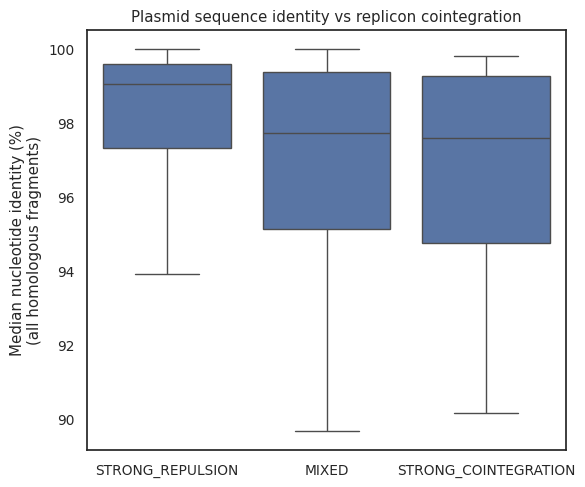


=== Pairwise comparisons (median_pid_all) ===
                                comparison  n_STRONG_REPULSION  n_MIXED  \
0                 MIXED > STRONG_REPULSION               792.0    716.0   
1  STRONG_COINTEGRATION > STRONG_REPULSION               792.0      NaN   
2             STRONG_COINTEGRATION > MIXED                 NaN    716.0   

   median_STRONG_REPULSION  median_MIXED   p_value  cliffs_delta  \
0                99.042185     97.723128  1.000000     -0.248848   
1                99.042185           NaN  0.999861     -0.292746   
2                      NaN     97.723128  0.682820     -0.038421   

   n_STRONG_COINTEGRATION  median_STRONG_COINTEGRATION  
0                     NaN                          NaN  
1                    55.0                        97.58  
2                    55.0                        97.58  


In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from itertools import combinations

BASE = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/cell_level/homology_sharing"

df = pd.read_csv(
    f"{BASE}/replicon_pair_pid_all.tsv",
    sep="\t"
)

# quedarnos con categorías válidas
df = df.dropna(subset=["category", "median_pid_all"])

order = ["STRONG_REPULSION", "MIXED", "STRONG_COINTEGRATION"]

# --------------------------------------------------
# 1. DESCRIPTIVA POR CATEGORÍA
# --------------------------------------------------
summary = (
    df.groupby("category")["median_pid_all"]
      .agg(
          n="count",
          median="median",
          mean="mean",
          q25=lambda x: x.quantile(0.25),
          q75=lambda x: x.quantile(0.75)
      )
      .loc[order]
)

print("\n=== Descriptive statistics (median_pid_all) ===")
print(summary)

# --------------------------------------------------
# 2. BOXPLOT
# --------------------------------------------------
plt.figure(figsize=(6,5))
sns.boxplot(
    data=df,
    x="category",
    y="median_pid_all",
    order=order,
    showfliers=False
)

plt.xlabel("")
plt.ylabel("Median nucleotide identity (%)\n(all homologous fragments)")
plt.title("Plasmid sequence identity vs replicon cointegration")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 3. PAIRWISE TESTS + EFFECT SIZE
# --------------------------------------------------
def cliffs_delta(x, y):
    """
    Cliff's delta: P(x > y) - P(x < y)
    """
    nx = len(x)
    ny = len(y)
    u, _ = mannwhitneyu(x, y, alternative="two-sided")
    return (2 * u) / (nx * ny) - 1

results = []

for c1, c2 in combinations(order, 2):
    x = df[df.category == c1]["median_pid_all"]
    y = df[df.category == c2]["median_pid_all"]

    u, p = mannwhitneyu(y, x, alternative="greater")
    delta = cliffs_delta(y, x)

    results.append({
        "comparison": f"{c2} > {c1}",
        f"n_{c1}": len(x),
        f"n_{c2}": len(y),
        f"median_{c1}": x.median(),
        f"median_{c2}": y.median(),
        "p_value": p,
        "cliffs_delta": delta
    })

stats_df = pd.DataFrame(results)

print("\n=== Pairwise comparisons (median_pid_all) ===")
print(stats_df)



=== Descriptive statistics (log10 fragment length) ===
                        n    median      mean       q25       q75
category                                                         
STRONG_REPULSION      792  2.915202  2.932884  2.887054  3.016824
MIXED                 716  2.915136  2.918388  2.875929  3.023252
STRONG_COINTEGRATION   55  2.921166  2.966363  2.913813  3.071281


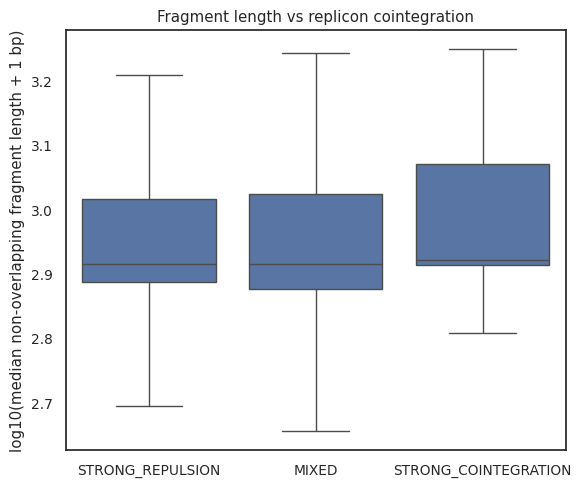


=== Pairwise comparisons ===
MIXED > STRONG_REPULSION | median MIXED=2.92, median STRONG_REPULSION=2.92, p=8.44e-01, Cliff's δ=-0.03
STRONG_COINTEGRATION > STRONG_REPULSION | median STRONG_COINTEGRATION=2.92, median STRONG_REPULSION=2.92, p=1.37e-02, Cliff's δ=0.18
STRONG_COINTEGRATION > MIXED | median STRONG_COINTEGRATION=2.92, median MIXED=2.92, p=1.20e-02, Cliff's δ=0.18


In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from itertools import combinations

BASE = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/cell_level/homology_sharing"

# --------------------------------------------------
# 1. LOAD COORDS (alignment blocks)
# --------------------------------------------------
coords = pd.read_csv(
    f"{BASE}/coords_all_hits.tsv",
    sep="\t"
)

coords = coords[[
    "replicon_pair",
    "plasmid_A",
    "plasmid_B",
    "start_A",
    "end_A"
]]

# --------------------------------------------------
# 2. COLLAPSE OVERLAPPING INTERVALS
# --------------------------------------------------
def collapse_intervals(intervals):
    if not intervals:
        return []
    intervals = sorted(intervals)
    merged = []
    cs, ce = intervals[0]
    for s, e in intervals[1:]:
        if s <= ce:
            ce = max(ce, e)
        else:
            merged.append((cs, ce))
            cs, ce = s, e
    merged.append((cs, ce))
    return merged

rows = []

for (pair, A, B), sub in coords.groupby(
    ["replicon_pair", "plasmid_A", "plasmid_B"]
):
    intervals = list(zip(sub.start_A, sub.end_A))
    merged = collapse_intervals(intervals)
    frag_lengths = [e - s + 1 for s, e in merged]

    rows.append({
        "replicon_pair": pair,
        "plasmid_A": A,
        "plasmid_B": B,
        "n_fragments": len(frag_lengths),
        "mean_fragment_bp": np.mean(frag_lengths),
        "median_fragment_bp": np.median(frag_lengths),
        "max_fragment_bp": max(frag_lengths),
        "sum_fragment_bp": sum(frag_lengths)
    })

plasm_frag = pd.DataFrame(rows)

# --------------------------------------------------
# 3. AGGREGATE TO REPLICON-PAIR LEVEL
# --------------------------------------------------
rep_rows = []

for pair, sub in plasm_frag.groupby("replicon_pair"):
    rep_rows.append({
        "replicon_pair": pair,
        "n_plasmid_pairs": len(sub),
        "median_fragment_bp": sub["median_fragment_bp"].median(),
        "mean_fragment_bp": sub["mean_fragment_bp"].mean(),
        "max_fragment_bp": sub["max_fragment_bp"].max(),
        "median_n_fragments": sub["n_fragments"].median()
    })

frag_rep = pd.DataFrame(rep_rows)

frag_rep[["repA", "repB"]] = frag_rep["replicon_pair"].str.split("__", expand=True)

# --------------------------------------------------
# 4. MERGE WITH COINTEGRATION
# --------------------------------------------------
coin = pd.read_csv(f"{BASE}/pairs_table.csv")

df = frag_rep.merge(
    coin,
    on=["repA", "repB"],
    how="left"
)

df = df.dropna(subset=["category", "median_fragment_bp"])

# --------------------------------------------------
# 5. STATISTICS + BOXPLOT
# --------------------------------------------------
df["log_median_fragment_bp"] = np.log10(df["median_fragment_bp"] + 1)

order = ["STRONG_REPULSION", "MIXED", "STRONG_COINTEGRATION"]

# Descriptiva
summary = (
    df.groupby("category")["log_median_fragment_bp"]
      .agg(
          n="count",
          median="median",
          mean="mean",
          q25=lambda x: x.quantile(0.25),
          q75=lambda x: x.quantile(0.75)
      )
      .loc[order]
)

print("\n=== Descriptive statistics (log10 fragment length) ===")
print(summary)

# Boxplot
plt.figure(figsize=(6,5))
sns.boxplot(
    data=df,
    x="category",
    y="log_median_fragment_bp",
    order=order,
    showfliers=False
)

plt.xlabel("")
plt.ylabel("log10(median non-overlapping fragment length + 1 bp)")
plt.title("Fragment length vs replicon cointegration")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 6. PAIRWISE TESTS (Cliff's delta)
# --------------------------------------------------
def cliffs_delta(x, y):
    nx = len(x)
    ny = len(y)
    u, _ = mannwhitneyu(x, y, alternative="two-sided")
    return (2 * u) / (nx * ny) - 1

print("\n=== Pairwise comparisons ===")

for c1, c2 in combinations(order, 2):
    x = df[df.category == c1]["log_median_fragment_bp"]
    y = df[df.category == c2]["log_median_fragment_bp"]

    u, p = mannwhitneyu(y, x, alternative="greater")
    delta = cliffs_delta(y, x)

    print(
        f"{c2} > {c1} | "
        f"median {c2}={y.median():.2f}, "
        f"median {c1}={x.median():.2f}, "
        f"p={p:.2e}, "
        f"Cliff's δ={delta:.2f}"
    )
